<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Tarea Semanal Nº1
#### Casandra Sotelino

## Actividad 1:
### Se utilizan las siguientes ecuaciones:
#### FFT :
$$X[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]\,e^{-j\frac{2\pi}{N}kn}$$ de manera tal que el resultado es normalizado por la cantidad de muestras $N$
#### Potencia (Parseval):
$$
P_x = \sum_{k=0}^{N-1}|X[k]|^2
$$
 Se realizan funciones con 1000 muestras (N = 1000) y sus transformadas de Fourier

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


#%% Definición de variables
N = 1000
f_sen = 2000
fs = f_sen * 10 
Px = 2

#%%Definición de funciones

def function_normal_noise(dc = 0, fs = 1000, pot = 10, nn = 1000):
    tt = np.arange(0, nn/fs, 1/fs) #vector tiempo (segundos)
    des_est = np.sqrt(pot)
    na = np.random.normal(dc, des_est, nn)
    return (tt, na)

def function_uniform_noise(dc = 0, fs = 1000, pot = 10, nn = 1000):
    tt = np.arange(0, nn/fs, 1/fs) #vector tiempo (segundos)
    H = (np.sqrt(12*pot) + dc) / 2
    na = np.random.uniform(low = dc - H, high = H, size = tt.size)
    return (tt, na)

def function_sen(vmax = 1, dc = 0, ff = 1, ph = 0, nn = 1000, fs = 1000):
    tt = np.arange(0, nn/fs, 1/fs) #vector tiempo (segundos)
    xx = vmax * np.sin(2 * np.pi * tt * ff * nn / fs + ph) + dc #funcion seno
    return(tt, xx)

def function_pwm(pot = 1, duty = 0.5, ff = 100, fs = 1000, nn = 1000):
    t = np.arange(0, nn/fs, 1/fs) #vector tiempo (segundos)
    A = np.sqrt(pot/duty)
    pwm = signal.square(2 * np.pi * ff * t, duty = duty)
    return (t, A * (pwm + 1)/2)


##### Se realiza una función seno de 2kHz (sen_2kHz), y se grafica dicha función y su transformada de Fourier (SEN_2kHz)

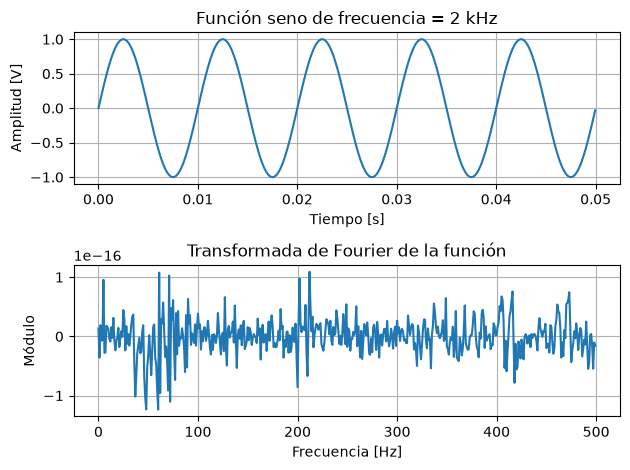

In [6]:
tt, sen_2kHz = function_sen(ff = f_sen, nn = N, fs = fs)
SEN_2kHz = np.fft.fft(sen_2kHz)/ N
# Graficos
plt.figure(1)

plt.subplot(2, 1, 1)
plt.plot(tt, sen_2kHz)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Función seno de frecuencia = 2 kHz")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(np.real(SEN_2kHz[:N//2]))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Módulo")
plt.title("Transformada de Fourier de la función")
plt.grid(True)

plt.tight_layout()

Se realiza la misma señal con 2 W de potencia media y desfasada en π/2.

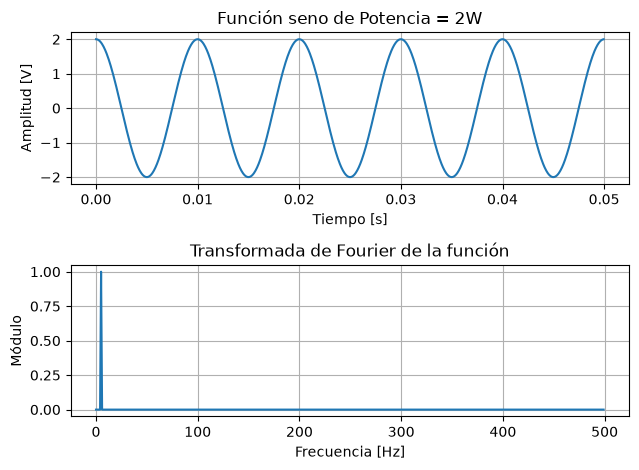

In [7]:
A = np.sqrt(2*Px)
tt, sen_2W = function_sen(vmax = A, ff = f_sen, fs = fs, ph = (np.pi/2))
SEN_2W = np.fft.fft(sen_2W)/N
#Gráficos
plt.figure(2)
plt.subplot(2, 1, 1)
plt.plot(tt, sen_2W)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Función seno de Potencia = 2W")
plt.grid(True)  

plt.subplot(2, 1, 2)
plt.plot(np.real(SEN_2W[:N//2]))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Módulo")
plt.grid(True)  
plt.title("Transformada de Fourier de la función")
plt.tight_layout()

Se realiza una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.

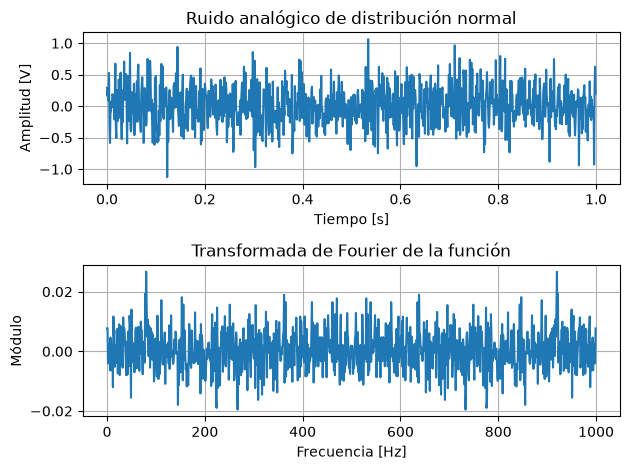

In [8]:
tt, na_N = function_normal_noise(dc = 0, pot = 0.1)
NA_N = np.fft.fft(na_N)/N
#Gráficos
plt.figure(3)
plt.subplot(2, 1, 1)
plt.plot(tt, na_N)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Ruido analógico de distribución normal")
plt.grid(True)  
plt.subplot(2, 1, 2)
plt.plot(np.real(NA_N))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Módulo")
plt.title("Transformada de Fourier de la función")
plt.grid(True)  
plt.tight_layout()

In [ ]:
Se realiza una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W. 

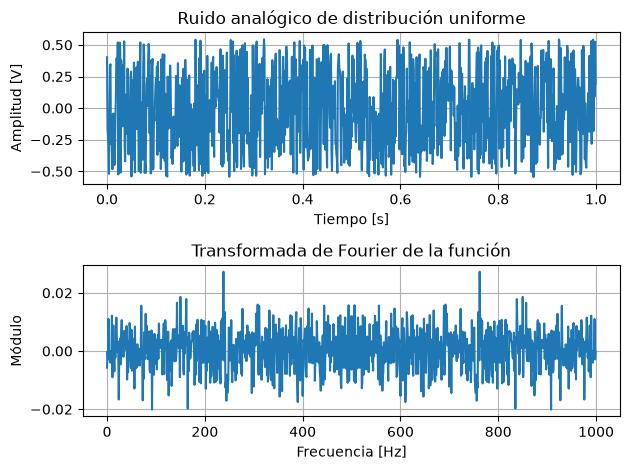

In [9]:
tt, na_U = function_uniform_noise(dc = 0, pot = 0.1)
NA_U = np.fft.fft(na_U)/N

#Gráficos
plt.figure(4)
plt.subplot(2, 1, 1)
plt.grid(True)  
plt.plot(tt, na_U)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Ruido analógico de distribución uniforme")
plt.subplot(2, 1, 2)
plt.plot(np.real(NA_U))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Módulo")
plt.grid(True)  
plt.title("Transformada de Fourier de la función")
plt.tight_layout()

Se realiza un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad (duty) del 50%.

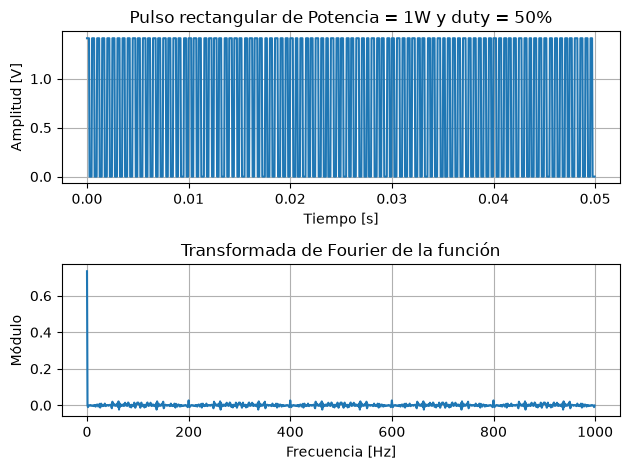

In [10]:
tt, pwm = function_pwm(pot = 1, ff = f_sen, fs = fs, nn = N)
PWM = np.fft.fft(pwm)/N

#Gráficos
plt.figure(5)
plt.subplot(2, 1, 1)
plt.plot(tt, pwm)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Pulso rectangular de Potencia = 1W y duty = 50%")
plt.grid(True)  
plt.subplot(2, 1, 2)
plt.plot(np.real(PWM))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Módulo")
plt.grid(True)  
plt.title("Transformada de Fourier de la función")
plt.tight_layout()

##Actividad 2:
<p align="center">
  <img src="./Ejercicio2_1jpg.jpg">
</p>
<p align="center">
  <img src="./Ejercicio2_2.jpg">
</p>